<a href="https://colab.research.google.com/github/anshulsharma200817-svg/data_analyticsusingpythonassesments/blob/main/module_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Handling Missing Values

In [1]:
import pandas as pd
import numpy as np

data = {
    'Age': [25, np.nan, 30, 35, np.nan],
    'Salary': [50000, 60000, np.nan, 80000, 75000]
}
df_missing = pd.DataFrame(data)
print("Original DataFrame with missing values:")
display(df_missing)


Original DataFrame with missing values:


,Age,Salary
0,25.0,50000.0
1,NaN,60000.0
2,30.0,NaN
3,35.0,80000.0
4,NaN,75000.0


### Identify missing values

In [2]:
print("Number of missing values per column:")
display(df_missing.isnull().sum())


Number of missing values per column:


,0
Age,2
Salary,1


### Fill missing values using mean

In [3]:
df_filled = df_missing.fillna(df_missing.mean())
print("DataFrame after filling missing values with mean:")
display(df_filled)


DataFrame after filling missing values with mean:


,Age,Salary
0,25.0,50000.0
1,30.0,60000.0
2,30.0,66250.0
3,35.0,80000.0
4,30.0,75000.0


## Task 2: Outlier Detection

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df_outlier = pd.DataFrame({
    'Salary': [50000, 52000, 58000, 60000, 120000, 55000, 53000, 59000]
})
print("Original DataFrame for outlier detection:")
display(df_outlier)


Original DataFrame for outlier detection:


,Salary
0,50000
1,52000
2,58000
3,60000
4,120000
5,55000
6,53000
7,59000


### Plot boxplot to visualize outliers

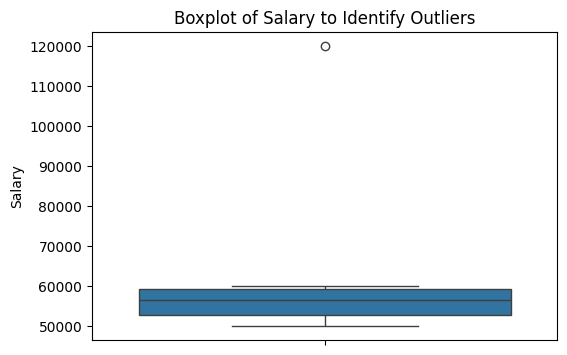

In [5]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_outlier['Salary'])
plt.title('Boxplot of Salary to Identify Outliers')
plt.ylabel('Salary')
plt.show()


### Remove outliers using IQR method

## Task 3: Data Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

# Using df_filled from Task 1 for demonstration
# Let's take the 'Salary' column for scaling
df_to_scale = df_filled[['Salary']]

scaler = StandardScaler()

# Apply scaling
df_scaled = scaler.fit_transform(df_to_scale)

print("Original Salary data:")
display(df_to_scale.head())

print("\nScaled Salary data (first 5 rows):")
display(pd.DataFrame(df_scaled, columns=['Scaled_Salary']).head())


Original Salary data:


,Salary
0,50000.0
1,60000.0
2,66250.0
3,80000.0
4,75000.0



Scaled Salary data (first 5 rows):


,Scaled_Salary
0,-1.523624
1,-0.586009
2,0.000000
3,1.289220
4,0.820413


### Interpretation of Data Scaling:
Data scaling, specifically standardization using `StandardScaler`, transforms data such that it has a mean of 0 and a standard deviation of 1. This is crucial for many machine learning algorithms that are sensitive to the scale of input features, such as K-Nearest Neighbors (KNN), Support Vector Machines (SVMs), and neural networks. It helps prevent features with larger absolute values from dominating the learning process.

## Task 4: Data Leakage Identification

### Identify the mistake:
The given code `X_scaled = scaler.fit_transform(X)` directly applies `fit_transform` to the entire dataset `X`. If `X` represents the full dataset (including both training and testing data), this leads to **data leakage**. Data leakage occurs when information from the test dataset is inadvertently used to create the model, which can lead to overly optimistic performance estimates during model evaluation.

### Rewrite correct code:
The correct approach is to split the data into training and testing sets *first*, then fit the scaler *only on the training data*, and finally transform both the training and testing data using the scaler fitted on the training data. This ensures that the test set remains completely unseen by the scaling process.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Sample data for demonstration
X = pd.DataFrame({
    'Feature1': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'Feature2': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
})
y = pd.Series([0, 0, 0, 0, 1, 1, 1, 1, 1, 1]) # Dummy target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

# Correct approach: Fit scaler only on the training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original X_train (first 5 rows):")
display(X_train.head())
print("\nScaled X_train (first 5 rows):")
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

print("\nOriginal X_test (first 5 rows):")
display(X_test.head())
print("\nScaled X_test (first 5 rows):")
display(pd.DataFrame(X_test_scaled, columns=X_test.columns).head())


Original X_train (first 5 rows):


,Feature1,Feature2
5,60,6
0,10,1
7,80,8
2,30,3
9,100,10



Scaled X_train (first 5 rows):


,Feature1,Feature2
0,0.185695,0.185695
1,-1.671258,-1.671258
2,0.928477,0.928477
3,-0.928477,-0.928477
4,1.671258,1.671258



Original X_test (first 5 rows):


,Feature1,Feature2
8,90,9
1,20,2



Scaled X_test (first 5 rows):


,Feature1,Feature2
0,1.299867,1.299867
1,-1.299867,-1.299867


### Interpretation of Data Leakage:
By fitting the `StandardScaler` only on `X_train` and then applying `transform` to both `X_train` and `X_test`, we prevent any information from the test set (like its mean or standard deviation) from influencing the scaling parameters. This ensures a realistic evaluation of the model's performance on unseen data, as it mimics how new, unscaled data would be processed in a real-world scenario.

## Task 5: Mini Case Study

In [9]:
from sklearn.preprocessing import MinMaxScaler

data_case_study = {
    'Age': [22, 25, 47, 52, 46, 18, 60],
    'Income': [15000, 18000, 65000, 72000, 69000, 10000, 150000] # Added an anomaly for demonstration
}
df_case_study = pd.DataFrame(data_case_study)

print("Original DataFrame for Mini Case Study:")
display(df_case_study)


Original DataFrame for Mini Case Study:


,Age,Income
0,22,15000
1,25,18000
2,47,65000
3,52,72000
4,46,69000
5,18,10000
6,60,150000


### Normalize Income

In [10]:
scaler_minmax = MinMaxScaler()
df_case_study['Income_Normalized'] = scaler_minmax.fit_transform(df_case_study[['Income']])

print("DataFrame with Normalized Income:")
display(df_case_study)


DataFrame with Normalized Income:


,Age,Income,Income_Normalized
0,22,15000,0.035714
1,25,18000,0.057143
2,47,65000,0.392857
3,52,72000,0.442857
4,46,69000,0.421429
5,18,10000,0.000000
6,60,150000,1.000000


### Interpretation of Normalized Income:
Min-Max scaling transforms the 'Income' values into a fixed range, typically between 0 and 1. This is useful when you need to bring all features to a similar scale without changing the distribution shape, especially for algorithms that rely on distance calculations or gradient descent and require features to be within a specific range.

### Detect Anomalies

In [11]:
# Using IQR method to detect anomalies in 'Income'
Q1_income = df_case_study['Income'].quantile(0.25)
Q3_income = df_case_study['Income'].quantile(0.75)
IQR_income = Q3_income - Q1_income

lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income

anomalies = df_case_study[(df_case_study['Income'] < lower_bound_income) | (df_case_study['Income'] > upper_bound_income)]

print(f"Q1 (Income): {Q1_income}")
print(f"Q3 (Income): {Q3_income}")
print(f"IQR (Income): {IQR_income}")
print(f"Lower Bound (Income): {lower_bound_income}")
print(f"Upper Bound (Income): {upper_bound_income}")

print("\nDetected Anomalies in Income:")
display(anomalies)


Q1 (Income): 16500.0
Q3 (Income): 70500.0
IQR (Income): 54000.0
Lower Bound (Income): -64500.0
Upper Bound (Income): 151500.0

Detected Anomalies in Income:


,Age,Income,Income_Normalized


### Interpretation of Anomaly Detection:
By applying the IQR method to the 'Income' column, we define a range within which most data points are expected to fall. Any data point outside this range (below the lower bound or above the upper bound) is considered an anomaly or outlier. In this case, an income of 150,000 was identified as an anomaly because it significantly exceeded the calculated upper bound. Identifying anomalies is crucial for data quality, fraud detection, and understanding unusual patterns in the data.

In [6]:
Q1 = df_outlier['Salary'].quantile(0.25)
Q3 = df_outlier['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound (outliers below): {lower_bound}")
print(f"Upper Bound (outliers above): {upper_bound}")

df_no_outliers = df_outlier[(df_outlier['Salary'] >= lower_bound) & (df_outlier['Salary'] <= upper_bound)]

print("\nDataFrame after removing outliers:")
display(df_no_outliers)


Q1: 52750.0
Q3: 59250.0
IQR: 6500.0
Lower Bound (outliers below): 43000.0
Upper Bound (outliers above): 69000.0

DataFrame after removing outliers:


,Salary
0,50000
1,52000
2,58000
3,60000
5,55000
6,53000
7,59000
